In [21]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
# import seaborn as sns
import anndata
from scipy import stats
import warnings 
import logging
import seaborn as sns

working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_GSEA/Cell death_v2"
os.chdir(working_dic)

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.logging.print_version_and_date()

sc.settings.verbosity = 1
warnings.filterwarnings('ignore')

# If you're using libraries like pandas, you can also set their display options
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs



# --- add this near the top (after imports) ---
COND_ORDER = [
    "Control",
    "Standard protocol",
    "Extended protocol",
    "Prematurely terminated",
    "PCMV",
    "Rejection",
]

COND_PALETTE = {
    "Control": "#EFE48E",
    "Standard protocol": "skyblue",
    "Extended protocol": "#08528f",
    "Prematurely terminated": "#C9B8D9",
    "PCMV": "#F0C096",
    "Rejection": "#E09E9E",
}


Running Scanpy 1.11.3, on 2025-08-18 12:00.


In [3]:
global_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/merging UMIs/CC_prepared_global_adata_raw_WITHOUT_lognorm.h5ad')

In [4]:
# Step 2: Preprocess - Normalize and Log Transform
sc.pp.normalize_total(global_adata)
sc.pp.log1p(global_adata)

In [5]:
pathways = {
    "Apoptosis intrinsic": [
        "BID", "BAD", "PMAIP1", "BMF", "CASP9",
        "APAF1", "DIABLO", "HTRA2", "ENDOG", "AIFM1", 
        "MAPK8", "MAPK9", "NR4A1", "TP53", "GADD45A", "TXNIP", "MYC"
    ],

    # Apoptosis (Extrinsic - Death Receptor) - Pro-Death Only
    "Apoptosis extrinsic": [
        "BID", "CASP8", "CASP10", "CASP3", "CASP7",
        "CASP6", "TRADD", "FADD", "FASLG", "MAPK8",
        "MAPK9", "EDN1", "TP53", "ICAM1", "NOS3", "MYC"
    ],

    # Oxidative stress promoting genes
    "Oxidative stress": [
        "CYP2E1", # NADPH oxidases   
        "PINK1", "BACH1", "NOX4",  
        "ATF4", 
        "SAT1", 
        "NDUFS1", "KEAP1", "NOS3", "OLR1", "XDH"
    ],
    
    # Necrosis & Necroptosis
    "Necrosis": [
        "RIPK1", "MLKL", "CYLD", 
        "PGAM5", "TNFRSF1A", 
        "CASP8", "TRADD", 
        "FADD", "ZBP1"
    ],

    # Pyroptosis
    "Pyroptosis": [
        "GSDMD", "GSDME",
        "PANX1", 
        "GBP2", 
        "DHX33", "NINJ1", "TXNIP", "NLRP3",
        "IL18",
        "P2RX7",
        "SREBF2", "LDLR"
    ],

    # Ferroptosis-Promoting
    "Ferroptosis (promoting)": [
        "ALOX15", "ACSL4", "LPCAT3", "GCLC", 
        "SLC39A8", "KEAP1", 
        "TFRC", "NCOA4", "RNF217", "TRIB3", "HSPA5",
        "POR", "IREB2", "STEAP3", 
        "SLC40A1", "SAT1", "LPCAT3",
        "HMOX1", "IREB2", "TXNRD1", "TP53", "BACH1"
    ],

    # Ferroptosis-Protective
    "Ferroptosis (protective)": [
        "GPX4", "GSS", "GSR", "SLC40A1", "CDKN1A",
        "GCLM", "SLC7A11", "NFE2L2",
        "SLC3A2",
        "CHMP5", "CHMP6", "AIFM2", "SESN2"
    ],

    # Autophagy
    "Autophagy": [
        "ULK2", "ATG16L1", "ATG3", "GABARAPL2", "AMBRA1",
        "ATG5", "ATG12", "FUNDC1", 
        "SQSTM1", "ULK1",
        "MAP1LC3A", "MAP1LC3B", 
        "GABARAPL1", "BECN1",
        "BNIP3", "BNIP3L"
    ],

    # Lysosomal Cell Death (LCD)
    "LCD": [
        "CTSL", "ATP6V0D1", "HSPA8", "GBA",
        "CTSD", "CTSB", "ASAH1", 
        "SMPD1", "MCOLN1", 
        "LAMP1", "LAMP2", "ATP6V1A"
    ]
}

# Combine all genes from all pathways into a single list
all_genes = [gene for genes in pathways.values() for gene in genes]

# Filter genes to only those present in the AnnData object
genes_in_data = [gene for gene in all_genes if gene in global_adata.var_names]


In [6]:
adata = global_adata.copy()

In [8]:
# Calculate gene set scores for each pathway
for pathway_name, gene_list in pathways.items():
    # Filter genes to only those present in the dataset
    genes_in_data = [gene for gene in gene_list if gene in adata.var_names]
    
    if len(genes_in_data) > 0:  # Only proceed if there are genes in the dataset
        sc.tl.score_genes(adata, gene_list=genes_in_data, score_name=pathway_name + "_score")
    else:
        print(f"No genes from {pathway_name} found in the dataset.")

# Save the AnnData object with the new scores
global_gsea_cd_adata = global_adata.write('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_GSEA/Cell death_v2/files/GSEA_celldeath.h5ad')

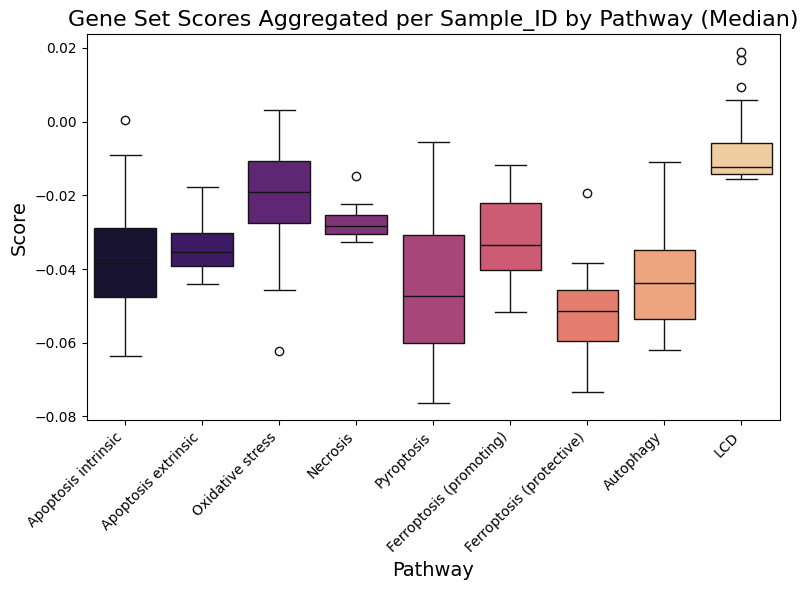

In [9]:
# It shows usean gene set scores across all samples for each pathway
# Create a DataFrame to store the gene set scores and Sample_ID
scores_df = pd.DataFrame()

# Extract gene set scores and Sample_ID
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        # Add the scores and Sample_ID to the DataFrame
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Add the Sample_ID information to the DataFrame
scores_df['Sample_ID'] = adata.obs['Sample_ID']

# Group by Sample_ID and calculate the mean score for each pathway
sample_scores_df = scores_df.groupby('Sample_ID').median()

# Melt the DataFrame for seaborn
sample_scores_melted = sample_scores_df.melt(var_name='Pathway', value_name='Score')

# Create a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    palette='magma'
)

# Customize the plot
plt.title('Gene Set Scores Aggregated per Sample_ID by Pathway (Median)', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

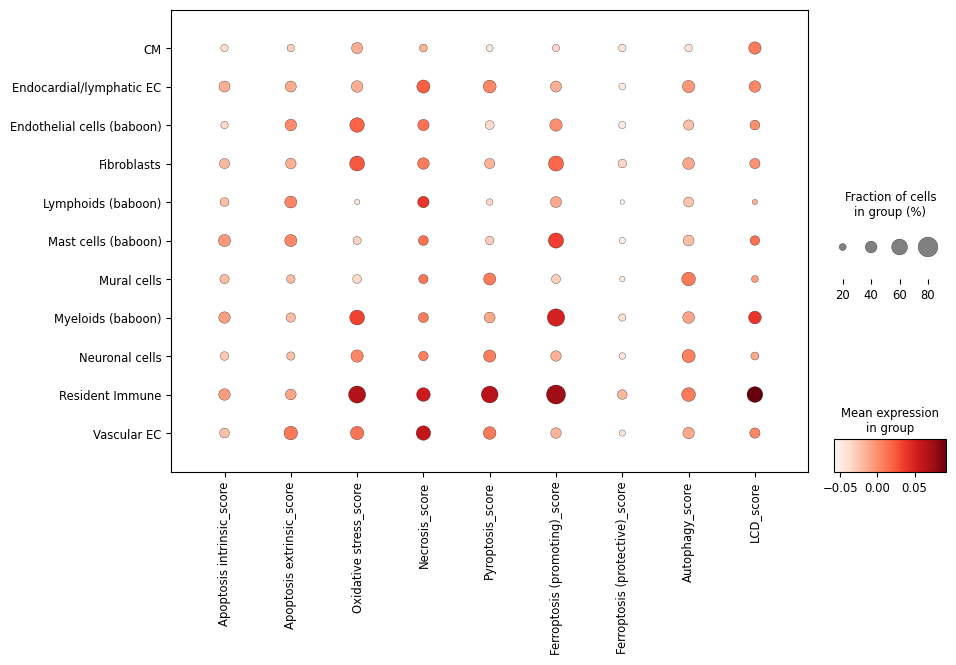

In [11]:
# Plot dot plot of gene set scores by cluster
sc.pl.dotplot(
    adata,
    var_names=[pathway_name + "_score" for pathway_name in pathways.keys()],
    groupby='cell_type',
    # cmap='coolwarm',
    figsize=(10, 6)
)

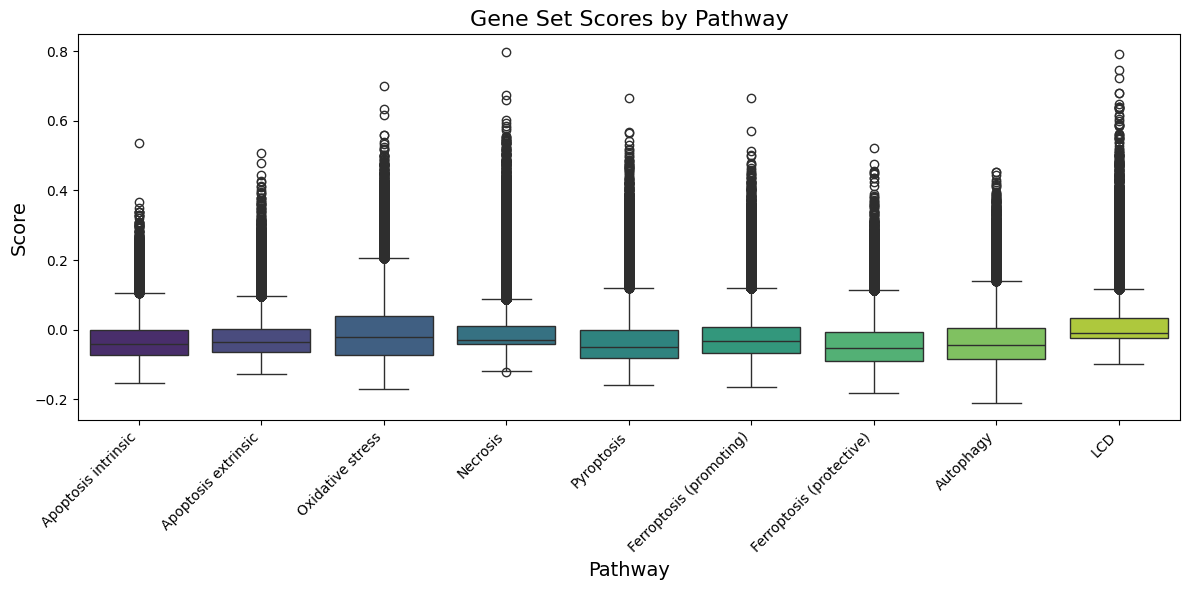

In [12]:
# Create a DataFrame to store the gene set scores
scores_df = pd.DataFrame()

# Extract gene set scores from adata.obs and add to the DataFrame
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Melt the DataFrame for seaborn
scores_df_melted = scores_df.melt(var_name='Pathway', value_name='Score')

# Create a box plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=scores_df_melted,
    x='Pathway',
    y='Score',
    palette='viridis'
)

# Customize the plot
plt.title('Gene Set Scores by Pathway', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

           Apoptosis intrinsic  Apoptosis extrinsic  Oxidative stress  Necrosis  Pyroptosis  Ferroptosis (promoting)  Ferroptosis (protective)  Autophagy       LCD
Sample_ID                                                                                                                                                          
B                    -0.038127            -0.039235         -0.028245 -0.031246   -0.031030                -0.041715                 -0.045688  -0.055637 -0.015565
E                    -0.063703            -0.044093         -0.012567 -0.030162   -0.073160                -0.040422                 -0.051175  -0.055537 -0.013988
F                    -0.056392            -0.042954         -0.045564 -0.026661   -0.059921                -0.042454                 -0.044628  -0.045111 -0.007749
G                    -0.045698            -0.039696         -0.010864 -0.028208   -0.040471                -0.039876                 -0.048026  -0.061954 -0.012223
PAV65           

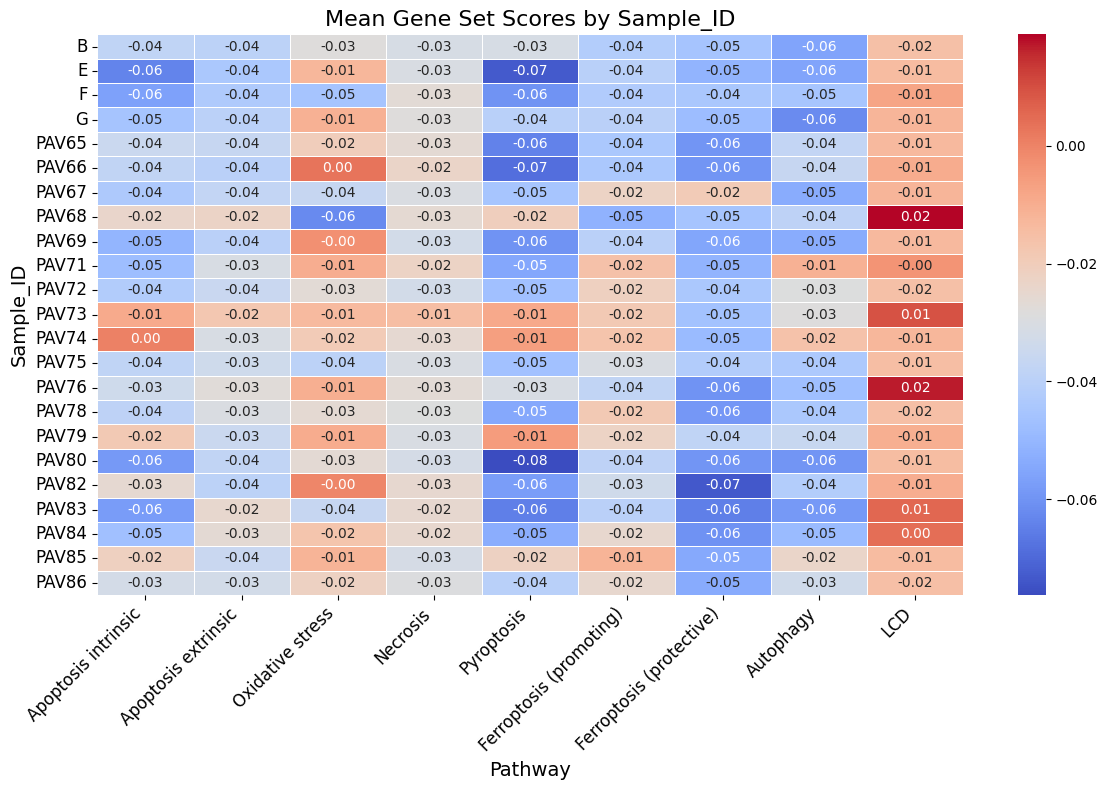

In [13]:
# Create a DataFrame to store the gene set scores and Sample_ID
scores_df = pd.DataFrame()

# Extract gene set scores and Sample_ID
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        # Add the scores and Sample_ID to the DataFrame
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Add the Sample_ID information to the DataFrame
scores_df['Sample_ID'] = adata.obs['Sample_ID']

# Group by Sample_ID and calculate the mean score for each pathway
sample_scores_df = scores_df.groupby('Sample_ID').median()

# Display the aggregated scores
print(sample_scores_df)

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    sample_scores_df,
    cmap='coolwarm',  # Color map
    annot=True,  # Annotate cells with values
    fmt=".2f",  # Format annotations to 2 decimal places
    linewidths=0.5  # Add lines between cells
)

# Customize the plot
plt.title('Mean Gene Set Scores by Sample_ID', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Sample_ID', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

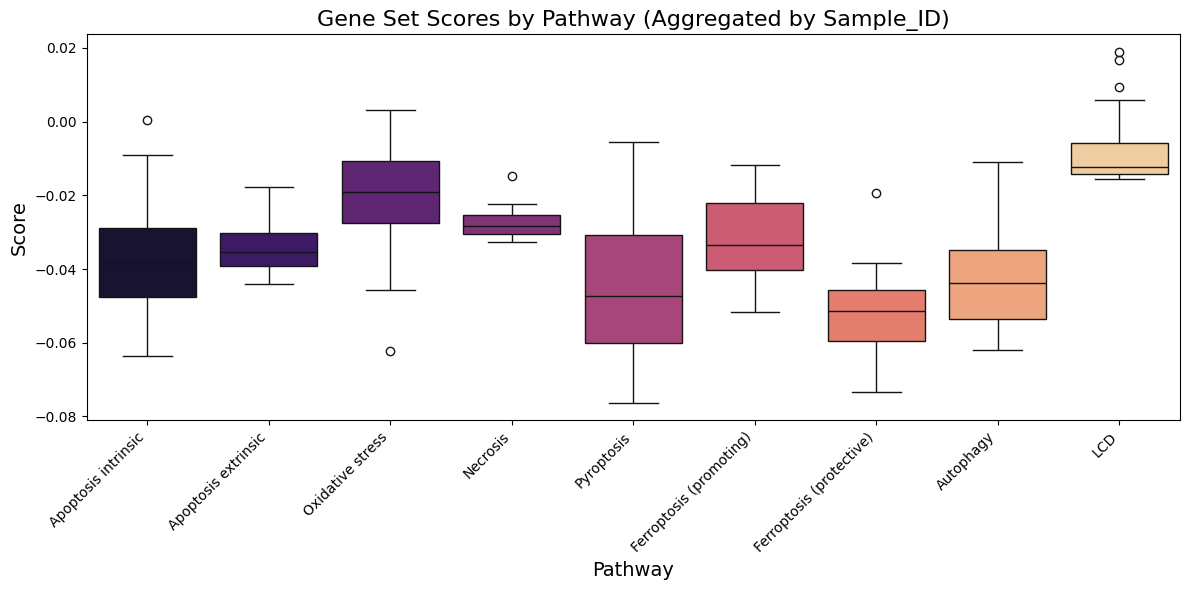

In [15]:
# It shows usean gene set scores across all samples for each pathway
# Create a DataFrame to store the gene set scores and Sample_ID
scores_df = pd.DataFrame()

# Extract gene set scores and Sample_ID
for pathway_name in pathways.keys():
    score_column = pathway_name + "_score"
    if score_column in adata.obs:
        # Add the scores and Sample_ID to the DataFrame
        scores_df[pathway_name] = adata.obs[score_column]
    else:
        print(f"Skipping {pathway_name}: No scores found in adata.obs.")

# Add the Sample_ID information to the DataFrame
scores_df['Sample_ID'] = adata.obs['Sample_ID']

# Group by Sample_ID and calculate the mean score for each pathway
sample_scores_df = scores_df.groupby('Sample_ID').median()

# Melt the DataFrame for seaborn
sample_scores_melted = sample_scores_df.melt(var_name='Pathway', value_name='Score')

# Create a box plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    palette='magma'
)

# Customize the plot
plt.title('Gene Set Scores by Pathway (Aggregated by Sample_ID)', fontsize=16)
plt.xlabel('Pathway', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()

In [16]:
adata

AnnData object with n_obs × n_vars = 186947 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets', 'Apoptosis intrinsic_score', 'Apoptosis extrinsic_score', 'Oxidative stress_score', 'Necrosis_score', 'Pyroptosis_score', 'Ferroptosis (pr

   Condition_subsets              Pathway     Score
0            Control  Apoptosis intrinsic -0.038127
1            Control  Apoptosis intrinsic -0.063703
2            Control  Apoptosis intrinsic -0.056392
3            Control  Apoptosis intrinsic -0.045698
4  Standard protocol  Apoptosis intrinsic -0.035233


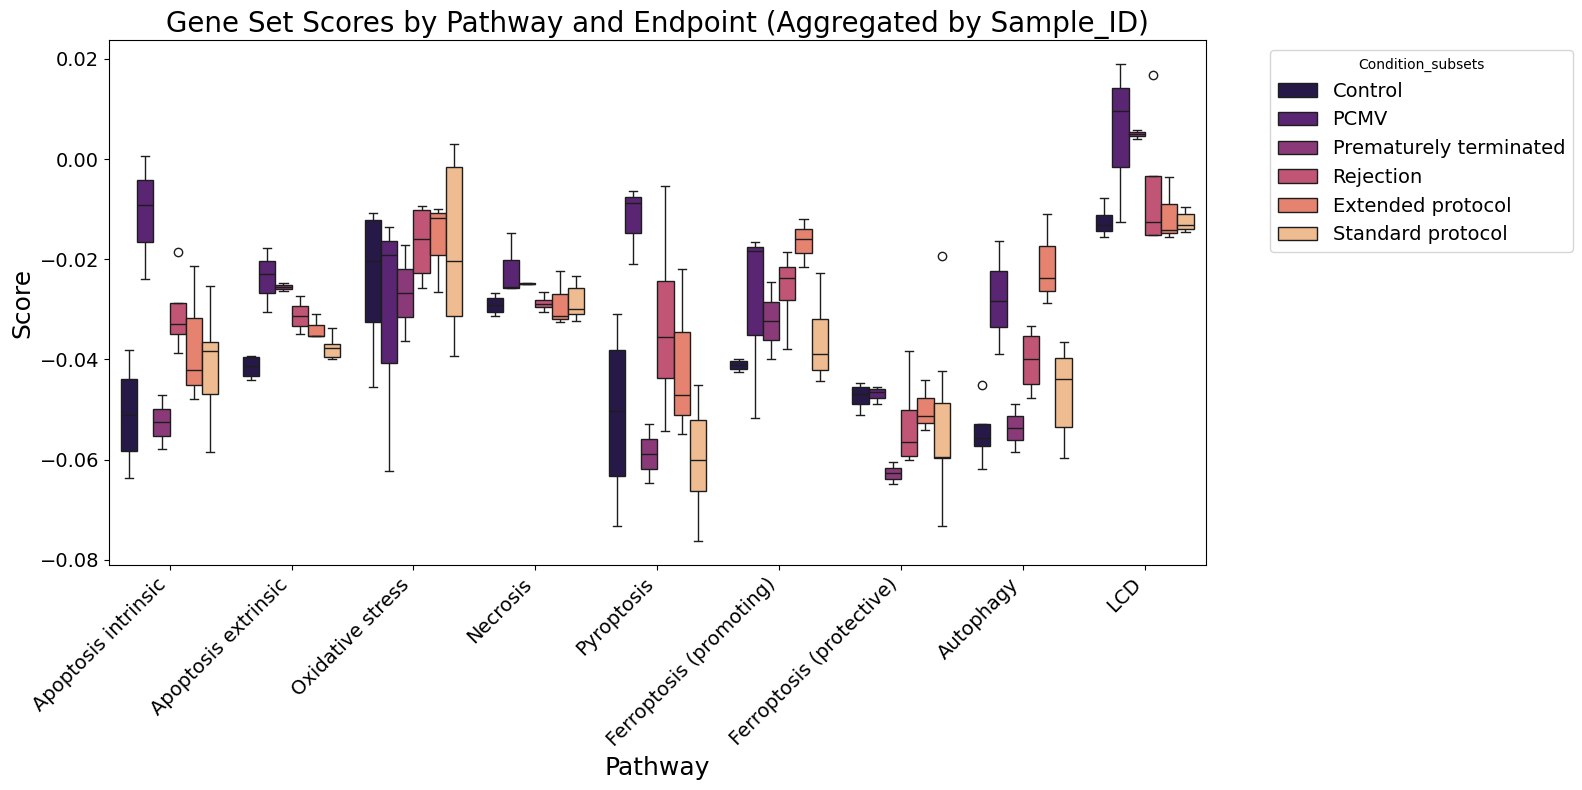

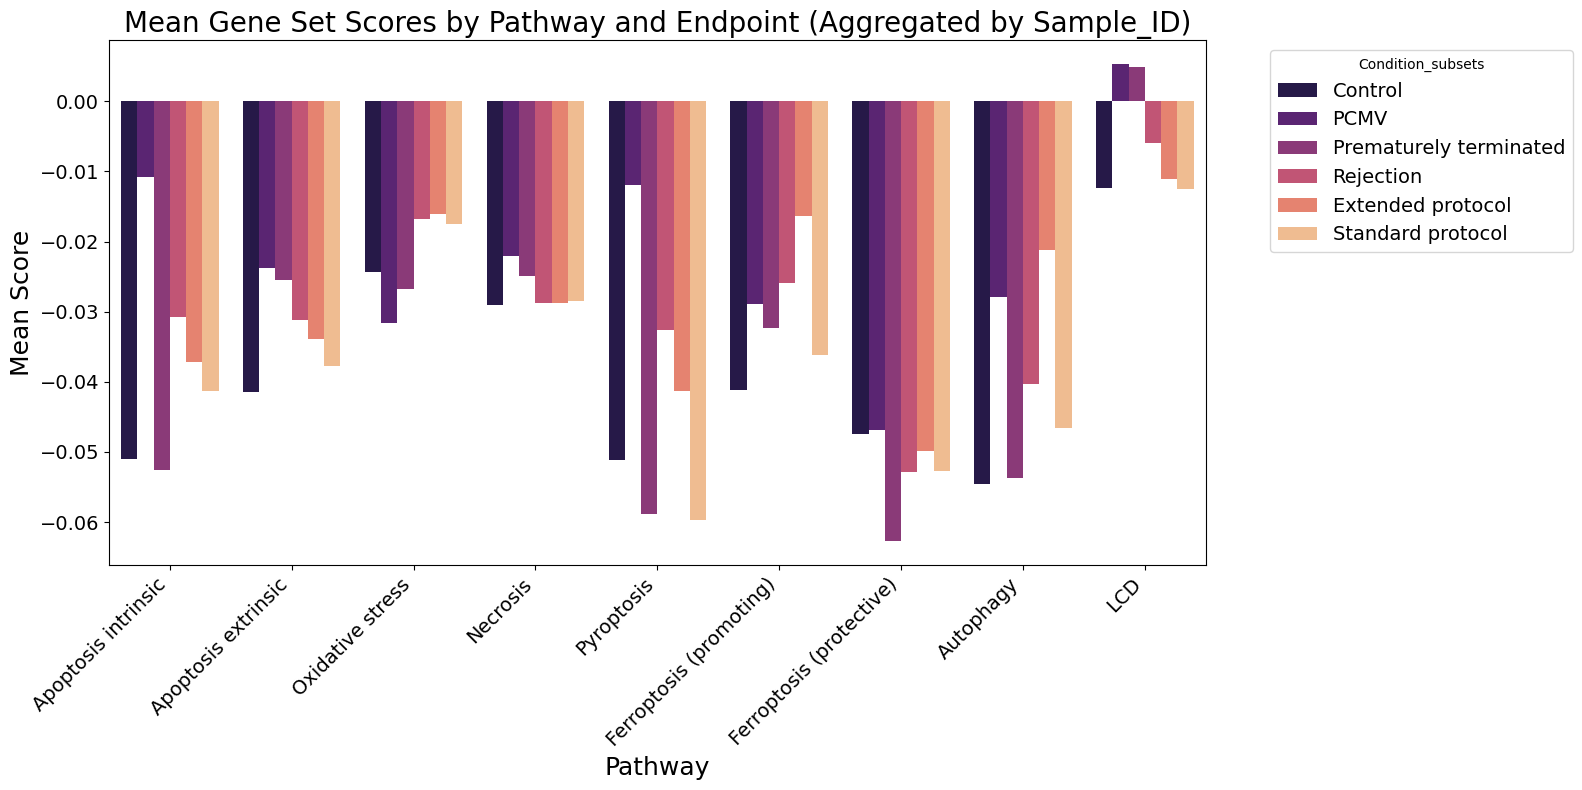

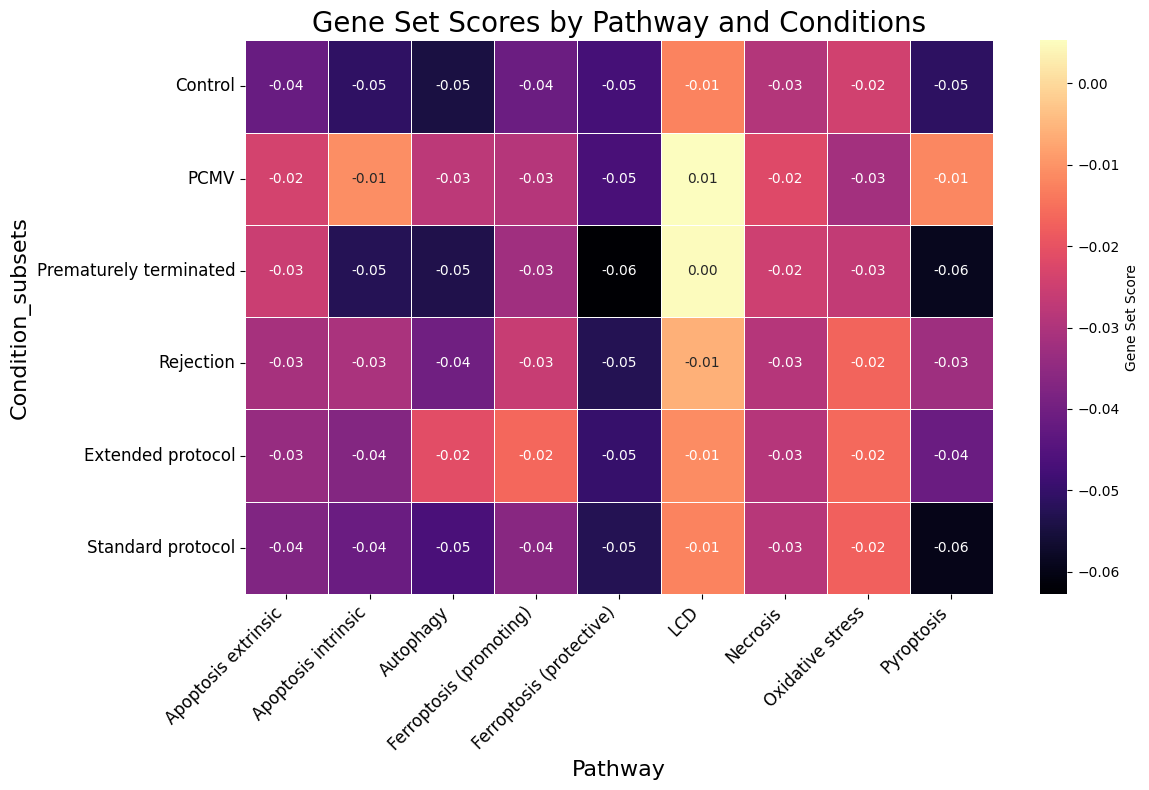

In [17]:
# Add new_endpoints information to the sample_scores_df DataFrame
sample_scores_df['Condition_subsets'] = adata.obs.groupby('Sample_ID')['Condition_subsets'].first()
# Melt the DataFrame for seaborn
sample_scores_melted = sample_scores_df.melt(
    id_vars='Condition_subsets',  # Include new_endpoints information
    var_name='Pathway', 
    value_name='Score'
)

# Verify the melted DataFrame
print(sample_scores_melted.head())

import seaborn as sns
import matplotlib.pyplot as plt

# Create a box plot
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',  # Color by new_endpoints
    palette='magma'
)

# Customize the plot
plt.title('Gene Set Scores by Pathway and Endpoint (Aggregated by Sample_ID)', fontsize=20)
plt.xlabel('Pathway', fontsize=18)
plt.ylabel('Score', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=14)  # Increase y-axis tick font size
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title='Condition_subsets')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()


# Create a bar plot
plt.figure(figsize=(16, 8))
sns.barplot(
    data=sample_scores_melted,
    x='Pathway',
    y='Score',
    hue='Condition_subsets',  # Color by new_endpoints
    palette='magma',
    estimator='mean',  # Use mean for aggregation
    ci=None  # Disable confidence intervals
)

# Customize the plot
plt.title('Mean Gene Set Scores by Pathway and Endpoint (Aggregated by Sample_ID)', fontsize=20)
plt.xlabel('Pathway', fontsize=18)
plt.ylabel('Mean Score', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=14)  # Increase y-axis tick font size
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title='Condition_subsets')  # Move legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the melted DataFrame to create a matrix for the heatmap
heatmap_data = sample_scores_melted.pivot_table(
    index='Condition_subsets',  # Rows: new_endpoints
    columns='Pathway',      # Columns: Pathways
    values='Score',         # Values: Gene set scores
    aggfunc='mean'          # Aggregate by mean (or median if preferred)
)

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap='magma',  # Color map
    annot=True,      # Annotate cells with values
    fmt=".2f",       # Format annotations to 2 decimal places
    linewidths=0.5,  # Add lines between cells
    cbar_kws={'label': 'Gene Set Score'}  # Add a label to the color bar
)

# Customize the plot
plt.title('Gene Set Scores by Pathway and Conditions', fontsize=20)
plt.xlabel('Pathway', fontsize=16)
plt.ylabel('Condition_subsets', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

In [32]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_pathway_scoring_by_celltype(
    adata,
    pathways: dict,
    cell_type_col: str,
    sample_col: str = "Sample_ID",
    condition_col: str = "Condition_subsets",
    cond_order: list = None,
    cond_palette: dict = None,
    outdir: str = "./per_celltype_pathway_scores",
    aggregate_func: str = "median",  # or "mean"
    pathway_order: list = None,
    figure_dpi: int = 200,
):
    """
    For each cell type:
      - creates (and saves) boxplot, mean barplot, and heatmap of pathway scores
      - writes CSVs (per-sample wide, melted long, and per-condition mean heatmap matrix)
    Assumes per-cell pathway scores live in adata.obs as <pathway>_score.
    If missing, it computes them using sc.tl.score_genes.
    """

    # ---------- setup ----------
    Path(outdir).mkdir(parents=True, exist_ok=True)
    if cond_order is None:
        cond_order = sorted(adata.obs[condition_col].dropna().unique().tolist())
    if cond_palette is None:
        # build a palette deterministically if none provided
        cond_palette = dict(zip(cond_order, sns.color_palette(n_colors=len(cond_order))))
    if pathway_order is None:
        pathway_order = list(pathways.keys())

    # helper for safe file names
    def _safe(s: str) -> str:
        return "".join(c if c.isalnum() or c in "._-+" else "_" for c in str(s))

    # ---------- ensure scores exist ----------
    missing = []
    for pname, genes in pathways.items():
        score_col = f"{pname}_score"
        if score_col not in adata.obs.columns:
            missing.append(pname)
    if len(missing) > 0:
        import scanpy as sc
        # only compute using genes present
        for pname in missing:
            genes = [g for g in pathways[pname] if g in adata.var_names]
            if len(genes) == 0:
                print(f"[warn] No genes for pathway '{pname}' found in var_names; skipping score.")
                continue
            sc.tl.score_genes(adata, gene_list=genes, score_name=f"{pname}_score")

    # choose aggregator
    aggfunc = np.median if aggregate_func.lower() == "median" else np.mean

    # ---------- loop over cell types ----------
    cell_types = adata.obs[cell_type_col].dropna().unique().tolist()
    cell_types = sorted(cell_types, key=str)

    for ct in cell_types:
        ct_dir = Path(outdir) / _safe(ct)
        ct_dir.mkdir(parents=True, exist_ok=True)
        print(f"\n=== Processing cell type: {ct} ===")

        ad_ct = adata[adata.obs[cell_type_col] == ct].copy()
        if ad_ct.n_obs == 0:
            print(f"[skip] No cells for '{ct}'.")
            continue

        # ---- build per-cell dataframe of scores (+ sample & condition) ----
        score_cols = []
        for pname in pathway_order:
            scname = f"{pname}_score"
            if scname in ad_ct.obs:
                score_cols.append(scname)
            else:
                print(f"[warn] Missing {scname} in '{ct}', will drop in plots.")
        if len(score_cols) == 0:
            print(f"[skip] No pathway scores present for '{ct}'.")
            continue

        df = ad_ct.obs[score_cols + [sample_col, condition_col]].copy()
        # rename columns to the plain pathway names
        col_map = {f"{p}_score": p for p in pathway_order if f"{p}_score" in df.columns}
        df = df.rename(columns=col_map)

        # ---- aggregate per Sample_ID (rows=samples) ----
        # use the chosen aggfunc across cells in the same sample (within this cell type)
        sample_scores_df = df.groupby(sample_col)[list(col_map.values())].agg(aggfunc)

        # attach the (first) condition per sample
        # (robust to mixed conditions per sample, but will take the first)
        sample_to_cond = (
            df[[sample_col, condition_col]]
            .dropna()
            .drop_duplicates()
            .groupby(sample_col)[condition_col]
            .first()
        )
        sample_scores_df[condition_col] = sample_to_cond.reindex(sample_scores_df.index)

        # enforce condition order & drop unseen levels for plotting
        present_conditions = [c for c in cond_order if c in sample_scores_df[condition_col].unique()]
        cond_palette_present = {c: cond_palette[c] for c in present_conditions if c in cond_palette}

        # ---- save wide per-sample CSV ----
        sample_csv_path = ct_dir / f"{_safe(ct)}__per_sample_{aggregate_func}.csv"
        sample_scores_df.to_csv(sample_csv_path, index=True)

        # ---- long/melted for seaborn ----
        melted = sample_scores_df.melt(
            id_vars=[condition_col],
            value_vars=[p for p in pathway_order if p in sample_scores_df.columns],
            var_name="Pathway",
            value_name="Score",
        )

        # keep only present conditions in the requested order
        melted = melted[melted[condition_col].isin(present_conditions)].copy()
        melted[condition_col] = pd.Categorical(melted[condition_col], categories=present_conditions, ordered=True)
        melted["Pathway"] = pd.Categorical(
            melted["Pathway"], categories=[p for p in pathway_order if p in melted["Pathway"].unique()], ordered=True
        )

        # ---- save melted CSV ----
        melted_csv_path = ct_dir / f"{_safe(ct)}__melted_{aggregate_func}.csv"
        melted.to_csv(melted_csv_path, index=False)

        # ---------- PLOTS ----------
        # 1) Boxplot by condition
        plt.figure(figsize=(18, 8))
        ax = sns.boxplot(
            data=melted,
            x="Pathway",
            y="Score",
            hue=condition_col,
            order=[p for p in pathway_order if p in melted["Pathway"].cat.categories],
            hue_order=present_conditions,
            palette=cond_palette_present,
        )
        plt.title(f"{ct} — Gene Set Scores by Pathway and Condition ({aggregate_func} per Sample_ID)", fontsize=18)
        plt.xlabel("Pathway", fontsize=14)
        plt.ylabel("Score", fontsize=14)
        plt.xticks(rotation=45, ha="right")
        plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title=condition_col)
        plt.tight_layout()
        boxplot_png = ct_dir / f"{_safe(ct)}__boxplot_{aggregate_func}.png"
        boxplot_pdf = ct_dir / f"{_safe(ct)}__boxplot_{aggregate_func}.pdf"
        plt.savefig(boxplot_png, dpi=figure_dpi)
        plt.savefig(boxplot_pdf)
        plt.close()

        # 2) Mean barplot by condition
        plt.figure(figsize=(18, 8))
        ax = sns.barplot(
            data=melted,
            x="Pathway",
            y="Score",
            hue=condition_col,
            order=[p for p in pathway_order if p in melted["Pathway"].cat.categories],
            hue_order=present_conditions,
            estimator=np.mean,
            ci=None,
            palette=cond_palette_present,
        )
        plt.title(f"{ct} — Mean Gene Set Scores by Pathway and Condition ({aggregate_func} per Sample_ID)", fontsize=18)
        plt.xlabel("Pathway", fontsize=14)
        plt.ylabel("Mean Score", fontsize=14)
        plt.xticks(rotation=45, ha="right")
        plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title=condition_col)
        plt.tight_layout()
        barplot_png = ct_dir / f"{_safe(ct)}__barplot_mean_{aggregate_func}.png"
        barplot_pdf = ct_dir / f"{_safe(ct)}__barplot_mean_{aggregate_func}.pdf"
        plt.savefig(barplot_png, dpi=figure_dpi)
        plt.savefig(barplot_pdf)
        plt.close()

        # 3) Heatmap (mean over samples within each condition)
        heatmap_df = (
            melted
            .groupby([condition_col, "Pathway"])["Score"]
            .mean()
            .reset_index()
            .pivot(index=condition_col, columns="Pathway", values="Score")
            .reindex(index=present_conditions)
        )
        # ensure column order
        heatmap_df = heatmap_df.reindex(columns=[p for p in pathway_order if p in heatmap_df.columns])

        # save heatmap matrix as CSV
        heatmap_csv = ct_dir / f"{_safe(ct)}__heatmap_matrix_mean_{aggregate_func}.csv"
        heatmap_df.to_csv(heatmap_csv)

        plt.figure(figsize=(12, 8))
        sns.heatmap(
            heatmap_df,
            cmap="magma",
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={"label": "Gene Set Score"},
        )
        plt.title(f"{ct} — Mean Gene Set Scores by Pathway × Condition", fontsize=18)
        plt.xlabel("Pathway", fontsize=14)
        plt.ylabel(condition_col, fontsize=14)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        heatmap_png = ct_dir / f"{_safe(ct)}__heatmap_mean_{aggregate_func}.png"
        heatmap_pdf = ct_dir / f"{_safe(ct)}__heatmap_mean_{aggregate_func}.pdf"
        plt.savefig(heatmap_png, dpi=figure_dpi)
        plt.savefig(heatmap_pdf)
        plt.close()

        print(f"Saved for '{ct}':")
        print(f"  CSV (per-sample): {sample_csv_path}")
        print(f"  CSV (melted):     {melted_csv_path}")
        print(f"  CSV (heatmap):    {heatmap_csv}")
        print(f"  Plots:            {boxplot_png}, {barplot_png}, {heatmap_png}")

# ---------------- How to run ----------------
# Choose the column that holds your cell types:
# e.g., "cell_type", "manual_celltype_annotation_Group1", "EC_subtype_annotation", etc.
cell_type_column_name = "cell_type"  # <-- CHANGE THIS to your column

run_pathway_scoring_by_celltype(
    adata=adata,
    pathways=pathways,
    cell_type_col=cell_type_column_name,
    sample_col="Sample_ID",
    condition_col="Condition_subsets",
    cond_order=COND_ORDER,
    cond_palette=COND_PALETTE,
    outdir="./CellDeath_GeneSetScores_byCellType",
    aggregate_func="median",          # or "mean"
    pathway_order=list(pathways.keys()),
    figure_dpi=300,
)



=== Processing cell type: CM ===
Saved for 'CM':
  CSV (per-sample): CellDeath_GeneSetScores_byCellType/CM/CM__per_sample_median.csv
  CSV (melted):     CellDeath_GeneSetScores_byCellType/CM/CM__melted_median.csv
  CSV (heatmap):    CellDeath_GeneSetScores_byCellType/CM/CM__heatmap_matrix_mean_median.csv
  Plots:            CellDeath_GeneSetScores_byCellType/CM/CM__boxplot_median.png, CellDeath_GeneSetScores_byCellType/CM/CM__barplot_mean_median.png, CellDeath_GeneSetScores_byCellType/CM/CM__heatmap_mean_median.png

=== Processing cell type: Endocardial/lymphatic EC ===
Saved for 'Endocardial/lymphatic EC':
  CSV (per-sample): CellDeath_GeneSetScores_byCellType/Endocardial_lymphatic_EC/Endocardial_lymphatic_EC__per_sample_median.csv
  CSV (melted):     CellDeath_GeneSetScores_byCellType/Endocardial_lymphatic_EC/Endocardial_lymphatic_EC__melted_median.csv
  CSV (heatmap):    CellDeath_GeneSetScores_byCellType/Endocardial_lymphatic_EC/Endocardial_lymphatic_EC__heatmap_matrix_mean_median